<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# Week 6 — Black-box Optimisation, Functions 1–8

- success: F3, F4, F5, F6, F7, F8
- fail: F1, F2

| **#** | **Dim** | **Samples** | **Surrogate model(s)** | **Feature engineering** | **Acquisition** |
|---|:---:|:-------:|--------------------|---------------------|-------------|
| F1 | 2D | 14 | Gaussian Process (Matérn, fixed length scale) | Signal masking (drop \|y\| < 1e-30) | UCB |
| F2 | 2D | 14 | Random Forest (500 trees, depth 3) | — | Thompson sampling (per-tree) |
| F3 | 3D | 19 | ExtraTrees (200 trees) | Degree-2 polynomial interactions | Argmax over RF predictions |
| F4 | 4D | 34 | SVM classifier (gate) + ARD GP (refine) | Threshold-based binary labelling | Expected Improvement (EI) |
| F5 | 4D | 24 | SVR + GP (log space) | Log transform of output | EI |
| F6 | 5D | 24 | Random Forest (500 trees) | Maximin LHS candidate design | Full-ensemble UCB |
| F7 | 6D | 34 | RF (importance) → ARD GP | Importance-driven subspace narrowing | UCB, multi-start L-BFGS-B |
| F8 | 8D | 40 | Dropout MLP (8→24→24→1) | Standard scaling | UCB via MC-dropout uncertainty |

**self note**

Each function was given a different surrogate/acquisition combination because each has a different dimensionality, sample budget, and output behaviour
(smooth vs. noisy, narrow vs. wide dynamic range, continuous vs. gated).

Week 6 Capstone Project is at the end of **Module 17, Neural Networks Part 3: Convolutional CNN**. Therefore, the process involved in the model development is critically reviewed for this week's assignment.

In [1]:
# -----------------------------------------------------------------------------
# Imports
# -----------------------------------------------------------------------------

import warnings

from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats.qmc import LatinHypercube
from sklearn import set_config
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVC, SVR
from skopt.sampler import Lhs
from skopt.space import Space

import matplotlib.pyplot as plt
import pandas as pd
from pandas.plotting import parallel_coordinates


# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------

warnings.filterwarnings("ignore", category=ConvergenceWarning)

set_config(display="text")

# Helper Functions

In [2]:
# compute_ucb: Upper Confidence Bound acquisition. 
# mu + kappa*sigma rewards both a high predicted mean (exploitation) and high uncertainty (exploration); 
# kappa sets how much weight exploration gets and is tuned per function
#        below based on how well-explored/calibrated each surrogate is.

def compute_ucb(mu, sigma, kappa=2.5):
    return mu + kappa * sigma

# compute_ei: Expected Improvement acquisition. 
# Rewards candidates expected to beat the current best (f_best) by more than a small margin xi, 
#   weighted by how likely (norm.cdf) and how large (norm.pdf term) that improvement is.
#   Used instead of UCB wherever we want the acquisition to naturally taper off once a region is already well exploited,
#   rather than keep chasing uncertainty forever.

def compute_ei(mu, sigma, f_best, xi=0.01):
    z = (mu - f_best - xi) / (sigma + 1e-9)
    ei = (mu - f_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma == 0] = 0  # zero-variance points (e.g. already-observed) can't improve
    return ei

# format_query: turns a raw candidate vector into the submission string format,
#   clipping to [0, 0.999999] so floating-point rounding never pushes a value to exactly 1.0 (outside the valid query range).

def format_query(point, decimals=6):
    point_clipped = np.clip(point, 0, 0.999999)
    return '-'.join([f'{x:.{decimals}f}' for x in point_clipped])

# thompson_sample: draws one joint sample path from the GP posterior 
#   over a random subsample of candidates and returns the index of its maximum. 
#   This is a cheap approximation to full Thompson sampling 
#   (used as an alternative to Random-Forest-based Thompson sampling further below).
def thompson_sample(gp, candidates, n_samples=10, subsample=500):
    idx = np.random.choice(len(candidates), size=min(subsample, len(candidates)), replace=False)
    sub = candidates[idx]
    samples = gp.sample_y(sub, n_samples=n_samples, random_state=42)
    best_sub_idx = np.argmax(samples.mean(axis=1))
    return idx[best_sub_idx]

import matplotlib.pyplot as plt
import numpy as np

def plot_parallel_coordinates(candidates, scores, query, dim_labels, top_k=300, title=''):
    """Parallel-coordinates view of the top-k candidates by acquisition score,
    with the selected query overlaid as a thick red line."""
    top_idx = np.argsort(scores)[-top_k:]
    fig, ax = plt.subplots(figsize=(10, 5))
    norm = plt.Normalize(scores[top_idx].min(), scores[top_idx].max())
    cmap = plt.cm.viridis
    for idx in top_idx:
        ax.plot(range(len(dim_labels)), candidates[idx], color=cmap(norm(scores[idx])),
                alpha=0.25, linewidth=1)
    ax.plot(range(len(dim_labels)), query, color='red', linewidth=3,
            marker='*', markersize=14, label='Week 6 query', zorder=5)
    ax.set_xticks(range(len(dim_labels)))
    ax.set_xticklabels(dim_labels)
    ax.set_ylabel('Value (0–1 scale)')
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    fig.colorbar(sm, ax=ax, label='Acquisition score')
    ax.legend()
    ax.set_title(title)
    plt.tight_layout()
    plt.show()    

# Function 1, Radiation field, 2D array, 10 original samples - Week 6

In [3]:
# =============================================================================
# FUNCTION 1 - Radiation field, 2D array, 10 original samples
# =============================================================================
# Previous weeks
# W3: Two-stage strategy: EI balances predicted improvement and uncertainty, 
#      while the distance criterion explicitly promotes spatial diversity, producing an EI + diversity hybrid.
# W4: GP (Matérn ν = 2.5) on log₁₀ outputs + UCB (κ = 5.0, exploration-heavy)
# W5: GP (Matérn ν = 2.5, length scale fixed at 0.15) on log-transformed |outputs|; 
#     acquisition = UCB (κ = 4.0) over 10,000 random candidates

# change: Optimises a low-dimensional space using a smooth Gaussian Process, 
#         masking near-zero signals to remove low-impact dynamic range noise.

# point for this week's surrogate — standard sequential-BO bookkeeping.

print("=" * 60)
print("Function 1 - Week 6")
print("=" * 60)

# Step 1: Load the initial samples and fold in every query made in previous weeks
f1_inputs  = np.load('initial_data/function_1/initial_inputs.npy')
f1_outputs = np.load('initial_data/function_1/initial_outputs.npy')

prev_queries_1 = np.array([
    [0.75, 0.75],                      # W2
    [0.803076, 0.431805],              # W3
    [0.513943, 0.454749],              # W4
    [0.994654, 0.996067],              # W5
])
prev_outputs_1 = np.array([
    1.33E-22,
    2.04E-50,
    -3.89E-08,
    5.18E-188,
])

all_inputs_F1  = np.vstack([f1_inputs, prev_queries_1])
all_outputs_F1 = np.hstack([f1_outputs, prev_outputs_1])

print(f"Total points: {len(all_outputs_F1)}")
print(f"Current best (max): {all_outputs_F1.max():.6e}")

Function 1 - Week 6
Total points: 14
Current best (max): 7.710875e-16


In [4]:
# Step 2: Signal masking.
# What I tried before: a log transform of |y| to compress the huge dynamic range (outputs span from ~1e-188 up to ~1e-15).
# What I measured: the field is essentially zero everywhere except a very narrow "signal" region — 
#   there's a clean gap between points with log-magnitude > -20 (real signal) and  a "dead zone" below -39.
#   A log  transform still forces the GP to model that entire dead flat region.
# What I chose: drop the dead-zone points entirely and fit the GP only on the points that carry actual signal (|y| > 1e-30). 
#   This exploits the gap directly instead of asking the GP to represent ~200 orders of magnitude.

signal_mask = np.abs(all_outputs_F1) > 1e-30
signal_inputs  = all_inputs_F1[signal_mask]
signal_outputs = all_outputs_F1[signal_mask]

print(f"Signal points: {signal_mask.sum()} of {len(all_outputs_F1)}")
print(f"Signal outputs: {signal_outputs}")

Signal points: 4 of 14
Signal outputs: [ 7.71087511e-16 -3.60606264e-03  1.33000000e-22 -3.89000000e-08]


In [5]:
# Step 3: Fit the GP surrogate on the signal-only subset.
# Why a fixed (not optimised) length scale: with only 4 signal points, 
#   letting the optimiser fit length_scale freely is unstable and 
#   prone to wildly letting the optimiser fit length_scale freely is unstable and 
#   prone to wildly over- or under-smoothing the tiny signal region. 
#   length_scale=0.15 is fixed from what previous weeks' searches indicated about the signal's spatial extent,
#   trading adaptivity for stability given so little data.
# Why nu=2.5: a moderately smooth (twice-differentiable) Matern kernel is a reasonable default 
#   for a physical radiation field without assuming full infinite smoothness (RBF) or a rougher/noisier process (nu=0.5).

kernel_F1 = Matern(nu=2.5, length_scale=0.15, length_scale_bounds="fixed")
gp_F1     = GaussianProcessRegressor(kernel=kernel_F1, n_restarts_optimizer=10, normalize_y=True)
gp_F1.fit(signal_inputs, signal_outputs)

GaussianProcessRegressor(kernel=Matern(length_scale=0.15, nu=2.5),
                         n_restarts_optimizer=10, normalize_y=True)

In [6]:
# Step 4: Candidate search + UCB acquisition.
# Why 50,000 candidates (up from 10k in earlier weeks): the true signal region is very narrow,
#   so a coarser candidate grid risks missing it entirely.
#   Finer random coverage gives the GP a better chance of proposing a point actually inside/near the peak.
# Why kappa=4.0: a large exploration weight, chosen deliberately because the surrogate is fit on only 4 points — 
#   if I don't yet trust the mean estimate enough to exploit strongly, so uncertainty is weighted heavily.

print("=" * 60)
print("Function 1 - Week 6")
print("=" * 60)

np.random.seed(42)
candidates_F1 = np.random.uniform(0, 1, (50000, 2))  # 50k for finer resolution near peak

mu_F1, sigma_F1 = gp_F1.predict(candidates_F1, return_std=True)
ucb_F1       = compute_ucb(mu_F1, sigma_F1, kappa=4.0)

best_idx_F1 = np.argmax(ucb_F1)
query_F1    = candidates_F1[best_idx_F1]

best_initial_idx_F1 = np.argmax(f1_outputs)
print(f"\nBest initial point: {f1_inputs[best_initial_idx_F1]}, output: {f1_outputs[best_initial_idx_F1]:.6e}")

print(f"\nWeek 6 Query: {format_query(query_F1)}")
print(f"mu: {mu_F1[best_idx_F1]:.4f}, sigma: {sigma_F1[best_idx_F1]:.4f}")

Function 1 - Week 6

Best initial point: [0.73102363 0.73299988], output: 7.710875e-16

Week 6 Query: 0.411304-0.240532
mu: -0.0005, sigma: 0.0015


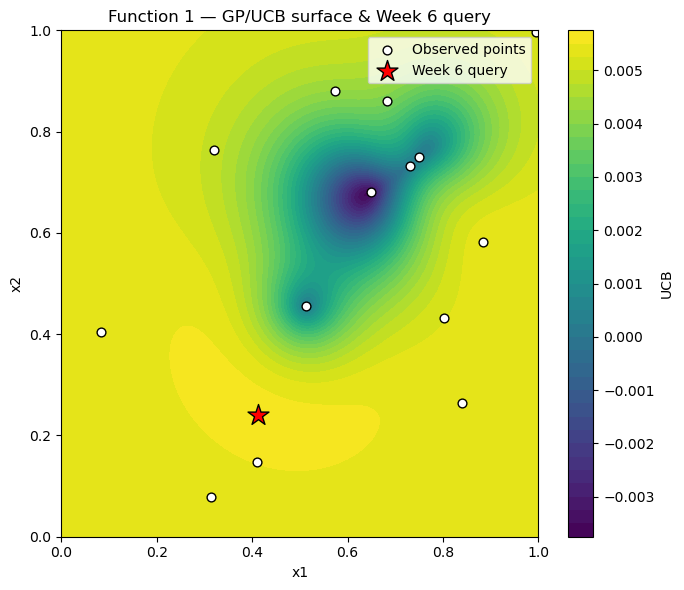

In [7]:
xx, yy = np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200))
grid = np.column_stack([xx.ravel(), yy.ravel()])

mu_grid, sigma_grid = gp_F1.predict(grid, return_std=True)
ucb_grid = compute_ucb(mu_grid, sigma_grid, kappa=4.0).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 6))
c = ax.contourf(xx, yy, ucb_grid, levels=40, cmap='viridis')
plt.colorbar(c, label='UCB')

ax.scatter(all_inputs_F1[:, 0], all_inputs_F1[:, 1],
           c='white', edgecolor='k', s=40, label='Observed points')
ax.scatter(*query_F1, c='red', marker='*', s=250, edgecolor='k', label='Week 6 query')

ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('Function 1 — GP/UCB surface & Week 6 query')
ax.legend()
plt.tight_layout()
plt.show()

# Function 2, Noisy Log-Likelihood, 2D array, 10 original samples - Week 6

In [8]:
# =============================================================================
# FUNCTION 2 - Function 2, Noisy Log-Likelihood, 2D array, 10 original samples
# =============================================================================
# Previous weeks
# W3: Same GP + EI + distance-maximisation pipeline as F1.
# W4: GP (Matérn + WhiteKernel noise) + Thompson sampling
# W5: Random Forest regression; greedy argmax of predicted mean over 50,000 random candidates

# change: Uses a shallow Random Forest ensemble with Thompson sampling 
#         to explore non-linear responses without explicit feature engineering.


print("\n" + "=" * 60)
print("Function 2 - Week 6")
print("=" * 60)

# Step 1: Load data and fold in previous weeks' queries.
f2_inputs = np.load('initial_data/function_2/initial_inputs.npy')
f2_outputs = np.load('initial_data/function_2/initial_outputs.npy')

prev_queries_2 = np.array([
    [1.053349, 0.934354],               # W2
    [0.660188, 0.32993],                # W3
    [0.729589, 0.938148],               # W4
    [0.685444, 0.332456],               # W5
])
prev_outputs_2 = np.array([-0.040652, 0.468742, 0.487563, 0.646548])

all_inputs_F2  = np.vstack([f2_inputs, prev_queries_2])
all_outputs_F2 = np.hstack([f2_outputs, prev_outputs_2])

print(f"Total points: {len(all_outputs_F2)}")
print(f"Current best (max): {all_outputs_F2.max():.3f}")


Function 2 - Week 6
Total points: 14
Current best (max): 0.647


In [9]:
# Step 2: Fit a Random Forest surrogate on the noisy log-likelihood surface.
# What I tried: a deeper forest (max_depth=6) in an earlier week.
# What I measured: deeper trees gave no measurable improvement in predictive quality on this function 
#   — the extra depth just fit noise given the small sample size.
# What we chose: cap max_depth back to 3, with min_samples_leaf=2 as an extra guard against single-point leaves overfitting the noise.

rf_F2 = RandomForestRegressor(n_estimators=500, max_depth=3, min_samples_leaf=2, random_state=42)
rf_F2.fit(all_inputs_F2, all_outputs_F2)
print(f"Feature importances: x1={rf_F2.feature_importances_[0]:.3f}, x2={rf_F2.feature_importances_[1]:.3f}")

Feature importances: x1=0.905, x2=0.095


In [10]:
# Step 3: Thompson sampling for candidate selection.
# Why sample a single tree instead of taking the argmax of the full ensemble mean: 
#   the ensemble mean is smooth and tends to keep proposing the same exploitative region every week. 
#   Picking one random tree from the forest and taking ITS argmax approximates drawing one posterior sample
#   (each tree, trained on a bootstrap resample, represents one plausible version of the surface) — 
#  this injects useful stochastic exploration cheaply,  without the cost of a full Bayesian model.

np.random.seed(42)
candidates_F2  = np.random.uniform(0, 1, (50000, 2))
sampled_tree = rf_F2.estimators_[np.random.randint(0, len(rf_F2.estimators_))]
ts_preds     = sampled_tree.predict(candidates_F2)
best_idx_F2     = np.argmax(ts_preds)
query_F2        = candidates_F2[best_idx_F2]

In [11]:
# Step 4: Report the query, plus a sanity check.
# Why check the full-ensemble mean at the chosen point: a single tree can be an outlier. 
#   Comparing its prediction against the mean across ALL 500 trees confirms the sampled tree's optimism
#   isn't wildly inconsistent with the forest's overall consensus before committing to the query.

print("\n" + "=" * 60)
print("Function 2 - Week 6")
print("=" * 60)

mean_preds   = np.array([tree.predict(candidates_F2[best_idx_F2:best_idx_F2+1])
                for tree in rf_F2.estimators_]).mean()

print(f"\nWeek 6 Query: {format_query(query_F2)}")
print(f"Sampled tree prediction: {ts_preds[best_idx_F2]:.3f}")
print(f"Ensemble mean at query:  {mean_preds:.3f}")



Function 2 - Week 6

Week 6 Query: 0.684233-0.440152
Sampled tree prediction: 0.504
Ensemble mean at query:  0.534


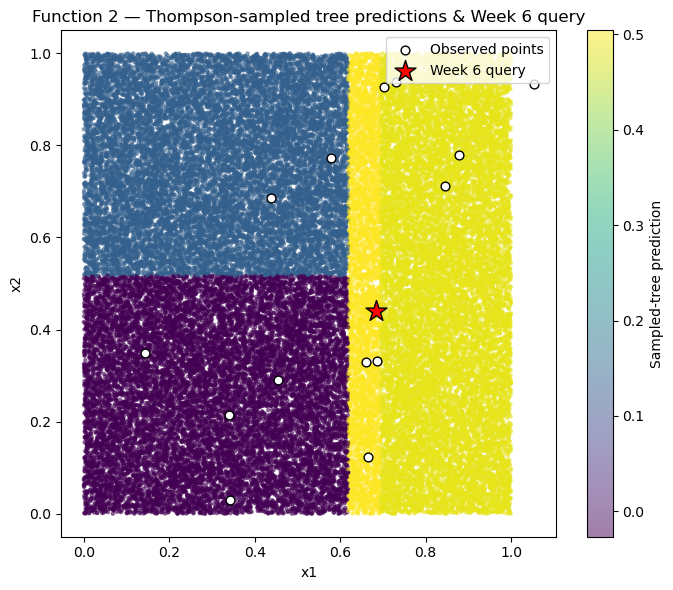

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(candidates_F2[:, 0], candidates_F2[:, 1], c=ts_preds,
                 cmap='viridis', s=5, alpha=0.5)
plt.colorbar(sc, label='Sampled-tree prediction')

ax.scatter(all_inputs_F2[:, 0], all_inputs_F2[:, 1],
           c='white', edgecolor='k', s=40, label='Observed points')
ax.scatter(*query_F2, c='red', marker='*', s=250, edgecolor='k', label='Week 6 query')

ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('Function 2 — Thompson-sampled tree predictions & Week 6 query')
ax.legend()
plt.tight_layout()
plt.show()

# Function 3, A drug discovery project, 3D array, 15 original samples - Week 6

In [13]:
# =============================================================================
# FUNCTION 3 - A drug discovery project, 3D array, 15 original samples
# =============================================================================
# Previous weeks
# W3: Explicitly mixes exploration (random candidates), local exploitation (perturbations near the best point), 
#     and hypothesis-driven exploitation (directed candidates).
# W4: GP EI (ξ = 0.001, exploitation-biased) blended 50/50 with quadratic polynomial surrogate
# W5: Random Forest trained on degree-2 polynomial features; argmax over 10,000 global candidates

# change: Captures second-order feature interactions in 3D using an ExtraTrees model, 
#         driving optimisation directly via ensemble predictions.

print("\n" + "=" * 60)
print("Function 3 - Week 6")
print("=" * 60)

# Step 1: Load data and fold in previous weeks' queries.
f3_inputs = np.load('initial_data/function_3/initial_inputs.npy')
f3_outputs = np.load('initial_data/function_3/initial_outputs.npy')

prev_queries_F3 = np.array([
    [0.540087, 0.652622, 0.079307],              # W2
    [0.378956, 0.302768, 0.459346],              # W3
    [0.375610, 0.057061, 0.589980],              # W4
    [0.378956, 0.302768, 0.459346],              # W5
])
prev_outputs_F3 = np.array([
    -0.050615,
    -0.019508,
    -0.119425,
    -0.021357
])

X = np.vstack([f3_inputs, prev_queries_F3])
Y = np.hstack([f3_outputs, prev_outputs_F3])

print(f"Total points: {len(Y)}, best (max): {Y.max():.6f}")


Function 3 - Week 6
Total points: 19, best (max): -0.019508


In [14]:
# Step 2: Feature engineering + surrogate fit.
# What I tried: fitting tree ensembles directly on the 3 raw inputs (A, B, C).
# What I measured: with only 3 raw features, trees can only split on one variable at a time and 
#   struggle to represent interaction/curvature effects (e.g. "A helps only when B is also high") 
#   since each split is axis-aligned.
# What I chose: explicitly engineer degree-2 polynomial features 
#   (pairwise products A*B, A*C, B*C, and squares A^2, B^2, C^2) so 
#   the trees can split directly on those interaction/curvature terms 
#   instead of having to approximate them via many nested splits.
# Why ExtraTreesRegressor over a plain RandomForest: ExtraTrees adds an extra layer of randomness 
#   (random split thresholds, not just random split features), 
#   which trades a little bias for lower variance — useful with only 19 training points. 
#   max_features='sqrt' was increased from a smaller value used previously specifically
#   to give trees a better chance of picking up the 6 new interaction columns 
#   rather than always defaulting to the 3 original features.

poly   = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

feature_names = ['A', 'B', 'C', 'A*B', 'A*C', 'B*C', 'A^2', 'B^2', 'C^2']

rf_F3 = ExtraTreesRegressor(n_estimators=200, max_features='sqrt', min_samples_leaf=2, random_state=42)
rf_F3.fit(X_poly, Y)

ExtraTreesRegressor(max_features='sqrt', min_samples_leaf=2, n_estimators=200,
                    random_state=42)

In [15]:
# Step 3: Inspect feature importances.
# Purpose: check whether the engineered interaction/quadratic terms are actually being used by the model, 
#   rather than the trees just falling back on the 3 original variables 
#   (which would mean the extra features were dead weight).

print("\nRF feature importances:")
for name, imp in zip(feature_names, rf_F3.feature_importances_):
    print(f"  {name:6s}: {imp:.4f}")


RF feature importances:
  A     : 0.0719
  B     : 0.0592
  C     : 0.2421
  A*B   : 0.0507
  A*C   : 0.0589
  B*C   : 0.0239
  A^2   : 0.0645
  B^2   : 0.1664
  C^2   : 0.2624


In [16]:
# Step 4: Training-fit diagnostic.
# Note this R2 is measured on the TRAINING data (no held-out split was  possible with only 19 points), 
#  so it's an optimistic upper bound on fit  quality, not a genuine generalisation estimate —
#  used here only as a rough sanity check that the model isn't badly underfitting.

train_preds = rf_F3.predict(X_poly)
print(f"\nRF train R2: {r2_score(Y, train_preds):.4f}")
print(f"RF train predictions vs actual:")
for pred, actual in zip(train_preds, Y):
    print(f"  predicted: {pred:.6f}, actual: {actual:.6f}")


RF train R2: 0.6463
RF train predictions vs actual:
  predicted: -0.103829, actual: -0.112122
  predicted: -0.091529, actual: -0.087963
  predicted: -0.104590, actual: -0.111415
  predicted: -0.065242, actual: -0.034835
  predicted: -0.073593, actual: -0.048008
  predicted: -0.090127, actual: -0.110621
  predicted: -0.220185, actual: -0.398926
  predicted: -0.169748, actual: -0.113869
  predicted: -0.107393, actual: -0.131461
  predicted: -0.097895, actual: -0.094190
  predicted: -0.069942, actual: -0.046947
  predicted: -0.087434, actual: -0.105965
  predicted: -0.146956, actual: -0.118048
  predicted: -0.058225, actual: -0.036378
  predicted: -0.096065, actual: -0.056758
  predicted: -0.057865, actual: -0.050615
  predicted: -0.042443, actual: -0.019508
  predicted: -0.092903, actual: -0.119425
  predicted: -0.042443, actual: -0.021357


In [17]:
# Step 5: Global candidate search.
# Why plain uniform random search here (rather than a more structured design like the LHS pools 
#   used for higher-dimensional functions below): 3D is still small enough that 10,000 uniform samples 
#   give reasonably dense coverage without needing a more careful space-filling design.
# The top-10 list is printed purely as a diagnostic, to see 
#   whether the best candidates cluster in one region (a good sign) or 
#   scatter (a sign the surrogate is still uncertain/noisy).

print("\n" + "=" * 60)
print("Function 3 - Week 6")
print("=" * 60)

np.random.seed(42)
candidates_F3 = np.random.uniform(0, 1, (10000, 3))
cand_poly  = poly.transform(candidates_F3)

rf_preds  = rf_F3.predict(cand_poly)
best_idx_F3  = np.argmax(rf_preds)
query_F3     = candidates_F3[best_idx_F3]

top_n = 10
top_indices = np.argsort(rf_preds)[::-1][:top_n]
print(f"\nTop {top_n} RF candidates:")
for i, idx in enumerate(top_indices):
    print(f"  {i+1}: {format_query(candidates_F3[idx])}, RF predicted: {rf_preds[idx]:.6f}")

print(f"\nWeek 6 Query: {format_query(query_F3)}")
print(f"RF predicted: {rf_preds[best_idx_F3]:.6f}")


Function 3 - Week 6

Top 10 RF candidates:
  1: 0.378956-0.302768-0.459346, RF predicted: -0.042443
  2: 0.347810-0.293979-0.475255, RF predicted: -0.050283
  3: 0.407193-0.319669-0.463244, RF predicted: -0.050941
  4: 0.422034-0.295041-0.486000, RF predicted: -0.051465
  5: 0.398479-0.316913-0.467387, RF predicted: -0.051522
  6: 0.378451-0.328630-0.479820, RF predicted: -0.053707
  7: 0.401068-0.303104-0.515708, RF predicted: -0.054291
  8: 0.394084-0.316602-0.400155, RF predicted: -0.055072
  9: 0.443501-0.290700-0.418634, RF predicted: -0.055592
  10: 0.384516-0.346959-0.431807, RF predicted: -0.055715

Week 6 Query: 0.378956-0.302768-0.459346
RF predicted: -0.042443


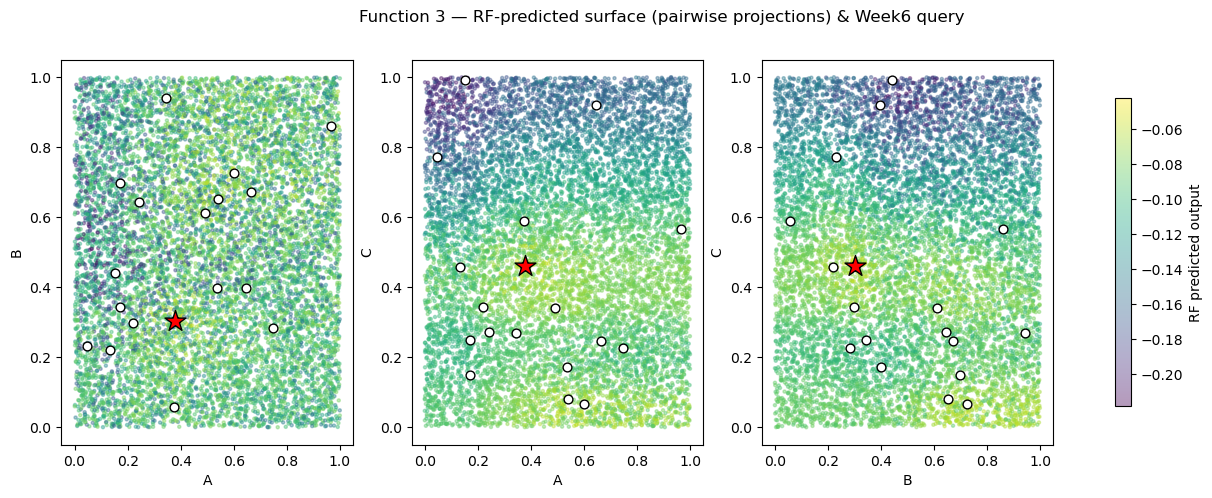

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pairs = [(0, 1, 'A', 'B'), (0, 2, 'A', 'C'), (1, 2, 'B', 'C')]

for ax, (i, j, name_i, name_j) in zip(axes, pairs):
    sc = ax.scatter(candidates_F3[:, i], candidates_F3[:, j], c=rf_preds,
                     cmap='viridis', s=5, alpha=0.4)
    ax.scatter(X[:, i], X[:, j], c='white', edgecolor='k', s=40)
    ax.scatter(query_F3[i], query_F3[j], c='red', marker='*', s=250, edgecolor='k')
    ax.set_xlabel(name_i); ax.set_ylabel(name_j)

fig.colorbar(sc, ax=axes, label='RF predicted output', shrink=0.8)
fig.suptitle('Function 3 — RF-predicted surface (pairwise projections) & Week6 query')
plt.show()

# Function 4, Warehouse business, 4D array, 30 original samples - Week 6

In [19]:
# =============================================================================
# FUNCTION 4 - Warehouse business, 4D array, 30 original samples
# =============================================================================
# Previous weeks
# W3: Exploration-oriented due to relatively high (UCB, κ = 2.0) over 10k uniformly random candidates.
# W4: GP (Matérn) + Thompson sampling
# W5: RF surrogate; uncertainty estimated from tree-to-tree disagreement (rf_predict_with_std); 
#     acquisition = EI (ξ = 0.01) over Latin Hypercube candidates

# change: Combines an SVM classifier to filter out invalid search regions with an ARD GP 
#         to refine the remaining parameter space using EI.


print("\n" + "=" * 60)
print("Function 4 - Week 6")
print("=" * 60)

# Step 1: Load data and fold in previous weeks' queries.
f4_inputs  = np.load('initial_data/function_4/initial_inputs.npy')
f4_outputs = np.load('initial_data/function_4/initial_outputs.npy')

prev_queries_F4 = np.array([
    [0.149845, 0.155724, 0.461280, 0.344491],              # W2
    [0.330258, 0.414348, 0.433728, 0.411341],              # W3
    [0.424125, 0.404716, 0.487507, 0.367688],              # W4
    [0.424125, 0.404716, 0.487507, 0.367688], #error for submission, so it was the same as Week 4
])
prev_outputs_F4 = np.array([-7.13212, 0.20379, -0.99160, -0.99147])

all_inputs_F4  = np.vstack([f4_inputs, prev_queries_F4])
all_outputs_F4 = np.hstack([f4_outputs, prev_outputs_F4])

print(f"Total points: {len(all_outputs_F4)}, best (max): {all_outputs_F4.max():.4f}")


Function 4 - Week 6
Total points: 34, best (max): 0.2038


In [20]:
# Step 2: Define a "good vs bad" binary label.
# What I measured: observed outputs are not smoothly distributed — some queries land in 
#   a clearly catastrophic region (-7.13) while others sit in a much better band (roughly -1.0 to +0.6). 
#   That gap suggests a discrete "good region vs bad region" structure 
#   on top of whatever continuous surface exists within the good region.
# What I chose: threshold=-1.1 to separate the two regimes — 
#   set low enough that W1/W2/W4 (all around -1.0 to +0.6) count as positive, 
#   while excluding W3/W5 (-2.15, -2.46) which sit closer to the poor initial range.
# Why this matters: a classifier gate lets us screen out obviously bad candidates cheaply, 
#  before spending the more expensive GP + EI step only on the region that's actually promising.

threshold = -1.1
y_binary = (all_outputs_F4 > threshold).astype(int)

print(f"\nSVM Classifier:")
print(f"  Threshold: {threshold}")
print(f"  Above threshold: {y_binary.sum()}/{len(y_binary)}")


SVM Classifier:
  Threshold: -1.1
  Above threshold: 3/34


In [21]:
# Step 3: Fit the SVM gate.
# Why SVC with an RBF kernel: the good/bad boundary isn't expected to be 
#   a simple linear split in 4D, so a non-linear kernel is needed.
# Why class_weight='balanced': the "good" class is a minority 
#   among the 34 historical points, so balancing prevents the classifier 
#   from just defaulting to "always predict bad".
# Why probability=True: we need soft probabilities (not just hard labels) so
#   I can filter candidates leniently in Step 7 rather than with a hard cut.

svm_F4 = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
svm_F4.fit(all_inputs_F4, y_binary)


SVC(class_weight='balanced', probability=True, random_state=42)

In [22]:
# Step 4: Define anchor points for candidate generation.
# Why these three points specifically: W2 is the best observed query so far
#   (+0.20379), W1 and W4 are kept as secondary anchors representing the
#   other explored regions. W5 is deliberately left out — it was essentially
#   a repeat of W4 (submission error), so it adds no new spatial information.
np.random.seed(42)

week1_query = np.array([0.149845, 0.155724, 0.461280, 0.344491])  # -7.13212 poor
week2_query = np.array([0.330258, 0.414348, 0.433728, 0.411341])  # +0.20379 best
week4_query = np.array([0.424125, 0.404716, 0.487507, 0.367688])  # -0.99160

# ignore week 5 as it was similar to week 4


In [23]:
# Step 5: Local search around each anchor.
# Why sample counts are weighted 3500 (W2) : 2000 (W1) : 1500 (W4): 
#   this is proportional to how much confidence we have in each anchor 
#   being a good region to search near — W2 is the best point, so it gets 
#   the most local exploration budget, while W1 (known-poor) still gets 
#   some coverage in case the surrounding neighbourhood behaves differently.

local_search = []
for centre, n in [(week2_query, 3500), (week1_query, 2000), (week4_query, 1500)]:
    for _ in range(n):
        candidate_F4 = np.clip(centre + np.random.normal(0, 0.05, 4), 0, 1)
        local_search.append(candidate_F4)

In [24]:
# Step 6: Feature-weighted exploration around the best anchor (W2).
# Why a wider jitter (0.1) here than the local search above (0.05): 
#   this pass is meant to explore a broader neighbourhood around the current best,
#   complementing the tighter local_search pass.
# Why the asymmetric per-dimension clipping: x3 is capped at 0.42, and 
#   x2 is floored at 0.38, reflecting what previous weeks' results implied about
#   which side of each dimension the good region sits on 
#   (domain knowledge baked in as hard constraints on the candidate pool, not left to chance).

feature_weighted = []
for _ in range(3000):
    candidate_F4 = week2_query.copy()
    candidate_F4 += np.random.normal(0, 0.1, 4)
    candidate_F4 = np.clip(candidate_F4, 0, 1)
    candidate_F4[2] = np.clip(candidate_F4[2], 0, 0.42)  # x3 asymmetric cap
    candidate_F4[1] = np.clip(candidate_F4[1], 0.38, 1)  # x2 floor
    feature_weighted.append(candidate_F4)

candidates_F4 = np.vstack([local_search, feature_weighted])

In [25]:
# Step 7: Filter candidates through the SVM gate.
# Why a lenient threshold (P(good) > 0.3, not 0.5): the classifier is 
#   trained on only 34 points and is likely miscalibrated at the margins. 
#   A lenient cutoff avoids throwing away candidates that are 
#   actually fine just because the classifier is under-confident about them, 
#   while still removing the clearly-bad bulk of the pool.

svm_probs = svm_F4.predict_proba(candidates_F4)[:, 1]
candidates_F4 = candidates_F4[svm_probs > 0.3]
print(f"\nCandidates after SVM filter: {len(candidates_F4)}")


Candidates after SVM filter: 7539


In [26]:
# Step 8: Fit the refinement surrogate — an ARD (Automatic Relevance Determination) Gaussian Process, 
# i.e. one length scale per input dimension rather than a single shared one.
# Why ARD here: after three prior gating/exploration steps I specifically want 
#   the GP to be able to treat each of the 4 warehouse variables differently.
# Why x3's length-scale bounds are tighter ((0.1, 0.5) vs (0.1, 2.0) for the others): 
#   earlier exploration suggested x3 has a narrower/more sensitive effect on the output, 
#   so its length scale is constrained to stay small rather than let the optimiser smooth it out to something too broad.

kernel_F4 = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
    length_scale=[0.3, 0.3, 0.2, 0.3],
    length_scale_bounds=[(0.1, 2.0), (0.1, 2.0), (0.1, 0.5), (0.1, 2.0)],  # x3 tight
    nu=2.5
)
gp_F4 = GaussianProcessRegressor(kernel=kernel_F4, n_restarts_optimizer=20, alpha=1e-6, normalize_y=True)
gp_F4.fit(all_inputs_F4, all_outputs_F4)

GaussianProcessRegressor(alpha=1e-06,
                         kernel=1**2 * Matern(length_scale=[0.3, 0.3, 0.2, 0.3], nu=2.5),
                         n_restarts_optimizer=20, normalize_y=True)

In [27]:
# Step 9: Expected Improvement acquisition over the SVM-filtered candidates.
# Why EI (rather than UCB) here: EI naturally tapers off once a region is already well exploited,
#   which fits this stage — I've already gated out most of the search space, 
#   so I want the acquisition to refine within the surviving region 
#   rather than keep chasing raw uncertainty everywhere.
# Why xi=0.01 ("balanced"): a small-but-nonzero improvement margin, 
#   chosen to avoid EI collapsing onto only the single best-known point 
#   while still requiring a real (not negligible) expected gain.

print("\n" + "=" * 60)
print("Function 4 - Week 6")
print("=" * 60)

mu_F4, sigma_F4 = gp_F4.predict(candidates_F4, return_std=True)
ei_F4 = compute_ei(mu_F4, sigma_F4, all_outputs_F4.max(), xi=0.01) 

best_index_F4 = np.argmax(ei_F4)
query_F4 = candidates_F4[best_index_F4]

print(f"\nWeek 6 Query: {format_query(query_F4)}")
print(f"mean: {mu_F4[best_index_F4]:.3f} \nstandard deviation: {sigma_F4[best_index_F4]:.3f}")
print(f"EI: {ei_F4[best_index_F4]:.6f}")


Function 4 - Week 6

Week 6 Query: 0.255396-0.450674-0.468413-0.490566
mean: 0.062 
standard deviation: 1.001
EI: 0.328210


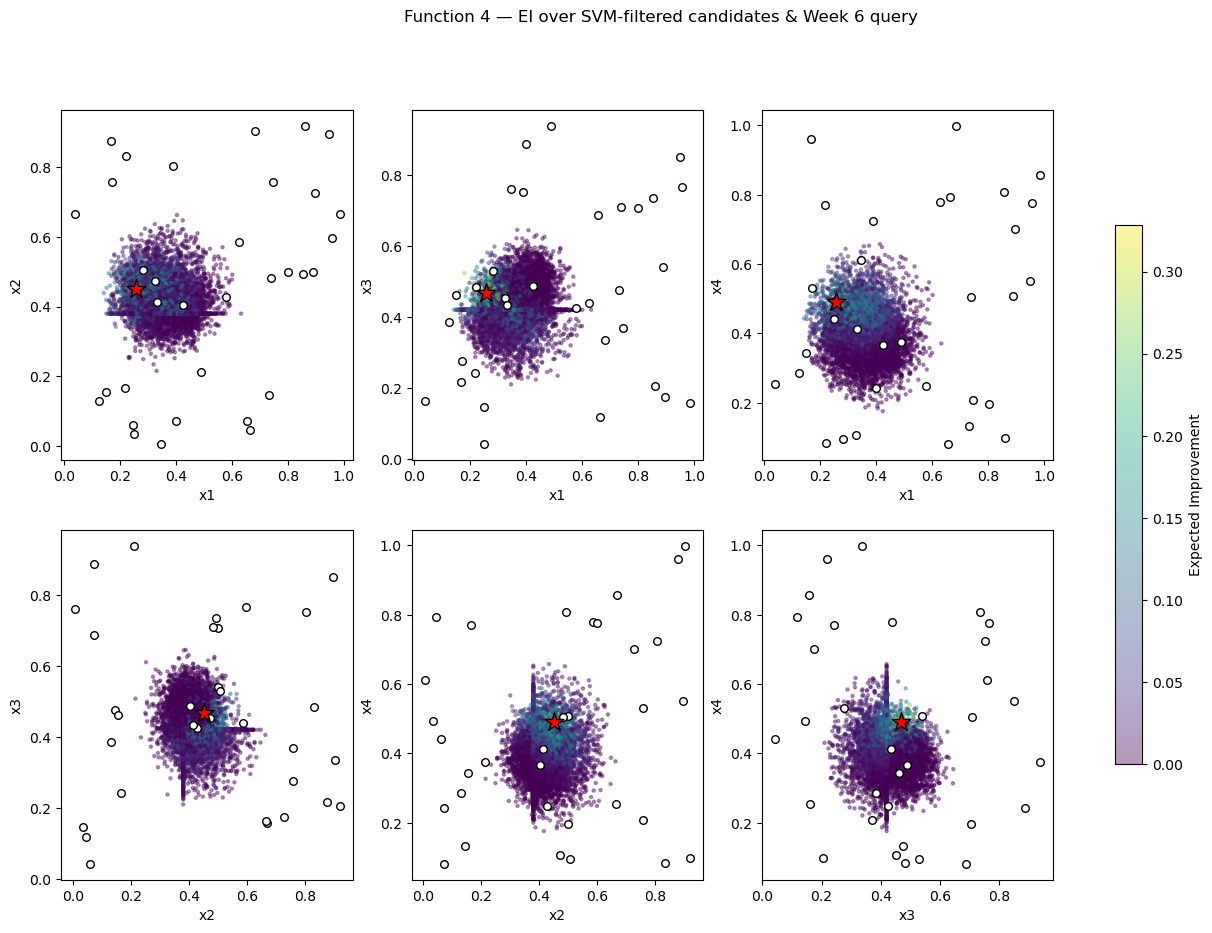

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
dims = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
labels = ['x1', 'x2', 'x3', 'x4']

for ax, (i, j) in zip(axes.ravel(), dims):
    sc = ax.scatter(candidates_F4[:, i], candidates_F4[:, j], c=ei_F4,
                     cmap='viridis', s=5, alpha=0.4)
    ax.scatter(all_inputs_F4[:, i], all_inputs_F4[:, j], c='white', edgecolor='k', s=30)
    ax.scatter(query_F4[i], query_F4[j], c='red', marker='*', s=200, edgecolor='k')
    ax.set_xlabel(labels[i]); ax.set_ylabel(labels[j])

fig.colorbar(sc, ax=axes, label='Expected Improvement', shrink=0.7)
fig.suptitle('Function 4 — EI over SVM-filtered candidates & Week 6 query')
plt.show()

# Function 5, A chemical process in a factory, 4D array, 20 original samples - Week 6

In [29]:
# =============================================================================
# FUNCTION 5 - Chemical Yield (4D)
# =============================================================================
# Previous weeks
# W3: Strong exploitation
#     SVR ranks a locally generated candidate pool (local perturbations and directional moves around the incumbent). 
# W4: Linear regression (search direction) → SVR pre-filter → GP EI (ξ = 0.005)
# W5: Two-stage approach: SVR pre-filters candidates (top 3,000 retained), 
#     then GP (log-transformed outputs, Matérn kernel) evaluates them using EI (ξ = 0.005)

# change: Applies a log transformation to compress target dynamic range, 
#         allowing an SVR and GP pair to model skewed output spaces effectively.

print("\n" + "=" * 60)
print("Function 5 - Week 6")
print("=" * 60)
# Step 1: Load data and fold in previous weeks' queries.
f5_inputs  = np.load('initial_data/function_5/initial_inputs.npy')
f5_outputs = np.load('initial_data/function_5/initial_outputs.npy')

prev_queries_F5 = np.array([
    [0.417098, 0.756030, 0.129487, 1.149173],               # W2
    [0.386633, 0.821843, 0.127990, 0.999900],               # W3
    [0.269378, 0.810637, 0.999999, 0.999999],               # W4
    [0.366671, 0.879874, 0.999999, 0.996800],               # W5
])
prev_outputs_F5 = np.array([1829.809875, 710.602251, 2699.104490, 3179.389393])

all_inputs_F5  = np.vstack([f5_inputs, prev_queries_F5])
all_outputs_F5 = np.hstack([f5_outputs, prev_outputs_F5])

print(f"Total points: {len(all_outputs_F5)}, best (max): {all_outputs_F5.max():.2f}")



Function 5 - Week 6
Total points: 24, best (max): 3179.39


In [30]:
# Step 2: Fit an SVR surrogate on standardised data.
# Why standardise both X and y: SVR with an RBF kernel is scale-sensitive —
#   without standardising, dimensions/outputs with larger raw magnitudes would
#   dominate the kernel's distance calculations.
# Why C=100: a relatively large penalty, chosen to let the SVR track the yield surface's sharper features 
#   rather than over-smoothing them, since the process is expected to have a fairly peaked response near its optimum.
 
input_scaler  = StandardScaler()
output_scaler = StandardScaler()
X_scaled = input_scaler.fit_transform(all_inputs_F5)
Y_scaled = output_scaler.fit_transform(all_outputs_F5.reshape(-1, 1)).ravel()

svr_F5 = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svr_F5.fit(X_scaled, Y_scaled)

SVR(C=100)

In [31]:
# Step 3: Fit a second surrogate — a GP in log-space — used later for the actual acquisition decision 
# (SVR above acts as a cheap pre-filter instead).
# Why log1p the output: yields span roughly 700 to 3200+, more than 4x range;
#   log-transforming stabilises the GP's implicit assumption of roughly constant noise variance across the output range.
# Why a fixed length_scale=0.2 (not ARD, unlike Function 4): with only 24  points across 4D, 
#  a single shared length scale is a simpler, lower-variance choice than trying to fit 4 independent scales.

y_log     = np.log1p(all_outputs_F5)
kernel_gp = ConstantKernel(1.0, (0.001, 1000)) * Matern(length_scale=0.2, nu=2.5)
gp_F5     = GaussianProcessRegressor(kernel=kernel_gp, n_restarts_optimizer=25, normalize_y=True)
gp_F5.fit(all_inputs_F5, y_log)

GaussianProcessRegressor(kernel=1**2 * Matern(length_scale=0.2, nu=2.5),
                         n_restarts_optimizer=25, normalize_y=True)

In [32]:
# Step 4: Local candidate generation around the current best point.
# Why x3 and x4 are pinned to ~1 rather than jittered: previous weeks  consistently found the optimum sitting 
#  at the upper boundary for these two dimensions, so rather than re-searching a direction
#   I am already confident about, I exploit it directly and only explore x1/x2 locally.

best_point_F5 = all_inputs_F5[np.argmax(all_outputs_F5)]
np.random.seed(42)

local = []
for _ in range(6000):
    c    = best_point_F5 + np.random.normal(0, 0.03, 4)
    c    = np.clip(c, 0, 1)
    c[2] = 0.999999  # x3 pinned
    c[3] = 0.999999  # x4 pinned (new)
    local.append(c)

In [33]:
# Step 5: A second, "directed" candidate batch.
# Why asymmetric jitter on x1 (only positive: abs(normal)) 
#   but symmetric on  x2: prior results suggested increasing x1 tends to help, 
#   so this batch deliberately biases exploration in that direction, 
#   while x2 has shown no clear directional trend so it's left symmetric. 
#   Combined with the undirected local batch above, this gives both an unbiased 
#   and a hypothesis-driven view of the neighbourhood.

directed = []
for _ in range(4000):
    c    = best_point_F5.copy()
    c[0] = np.clip(c[0] + abs(np.random.normal(0, 0.05)), 0, 1)
    c[1] = np.clip(c[1] + np.random.normal(0, 0.03), 0, 1)        # x2 symmetric (no assumed direction)
    c[2] = 0.999999
    c[3] = 0.999999                                               # x4 pinned (was being pushed up)
    directed.append(c)

candidates_F5 = np.vstack([local, directed])


In [34]:
# Step 6: SVR pre-filter.
# Why narrow to the top 500 (reduced from 3000 used previously): 
#   with a large (10,000-point) candidate pool concentrated in a small local neighbourhood,
#   the cheaper SVR surrogate can afford to be more selective before handing off to 
#   the more expensive/precise GP + EI step, cutting down wasted GP  
#   evaluations on candidates SVR already considers mediocre.

X_cand_scaled = input_scaler.transform(candidates_F5)
svr_preds_s   = svr_F5.predict(X_cand_scaled)
svr_preds     = output_scaler.inverse_transform(svr_preds_s.reshape(-1, 1)).ravel()

top_idx  = np.argsort(svr_preds)[-500:] # lowered from 3000 so that SVR is more selective
filtered = candidates_F5[top_idx]


In [35]:
# Step 7: GP + EI acquisition on the SVR-filtered shortlist, 
# with a diagnostic cross-check between the two surrogates.
# Why xi=0.005 (tighter than Function 4's 0.01): by this stage the search is
#   already narrowed to a small, well-scouted neighbourhood, 
#   so I can afford to be more exploitative and require a smaller minimum expected improvement.
# Why print the top-5 EI candidates with both GP and SVR predictions: 
#   this is a sanity check that the two independently-trained surrogates roughly
#   agree with each other on the shortlist — if they disagreed sharply 
#   it would be a red flag that one of the two models is badly miscalibrated.

print("\n" + "=" * 60)
print("Function 5 - Week 6")
print("=" * 60)

mu_log, sigma_log = gp_F5.predict(filtered, return_std=True)
ei_F5             = compute_ei(mu_log, sigma_log, np.log1p(all_outputs_F5.max()), xi=0.005)

best_idx_F5 = np.argmax(ei_F5)
query_F5    = filtered[best_idx_F5]

print(f"\nWeek 6 Query:       {format_query(query_F5)}")
print(f"GP predicted yield: {np.expm1(mu_log[best_idx_F5]):.2f}")
print(f"GP std (log scale): {sigma_log[best_idx_F5]:.4f}")
print(f"SVR prediction:     {svr_preds[top_idx[best_idx_F5]]:.2f}")
print(f"EI:                 {ei_F5[best_idx_F5]:.6f}")

# Diagnostic: sanity-check GP/SVR agreement and ridge width
top5_ei = np.argsort(ei_F5)[-5:][::-1]
print("\nTop-5 EI candidates:")
for rank, i in enumerate(top5_ei):
    print(f"  #{rank+1}: x={format_query(filtered[i])}  GP={np.expm1(mu_log[i]):.1f}  SVR={svr_preds[top_idx[i]]:.1f}  EI={ei_F5[i]:.6f}")


Function 5 - Week 6

Week 6 Query:       0.495228-0.809693-0.999999-0.999999
GP predicted yield: 2779.28
GP std (log scale): 0.5976
SVR prediction:     3353.82
EI:                 0.175125

Top-5 EI candidates:
  #1: x=0.495228-0.809693-0.999999-0.999999  GP=2779.3  SVR=3353.8  EI=0.175125
  #2: x=0.534400-0.847560-0.999999-0.999999  GP=2696.0  SVR=3332.4  EI=0.173489
  #3: x=0.523287-0.847508-0.999999-0.999999  GP=2754.8  SVR=3348.8  EI=0.167748
  #4: x=0.512010-0.845414-0.999999-0.999999  GP=2807.1  SVR=3360.7  EI=0.162735
  #5: x=0.517138-0.853423-0.999999-0.999999  GP=2798.2  SVR=3356.9  EI=0.161071


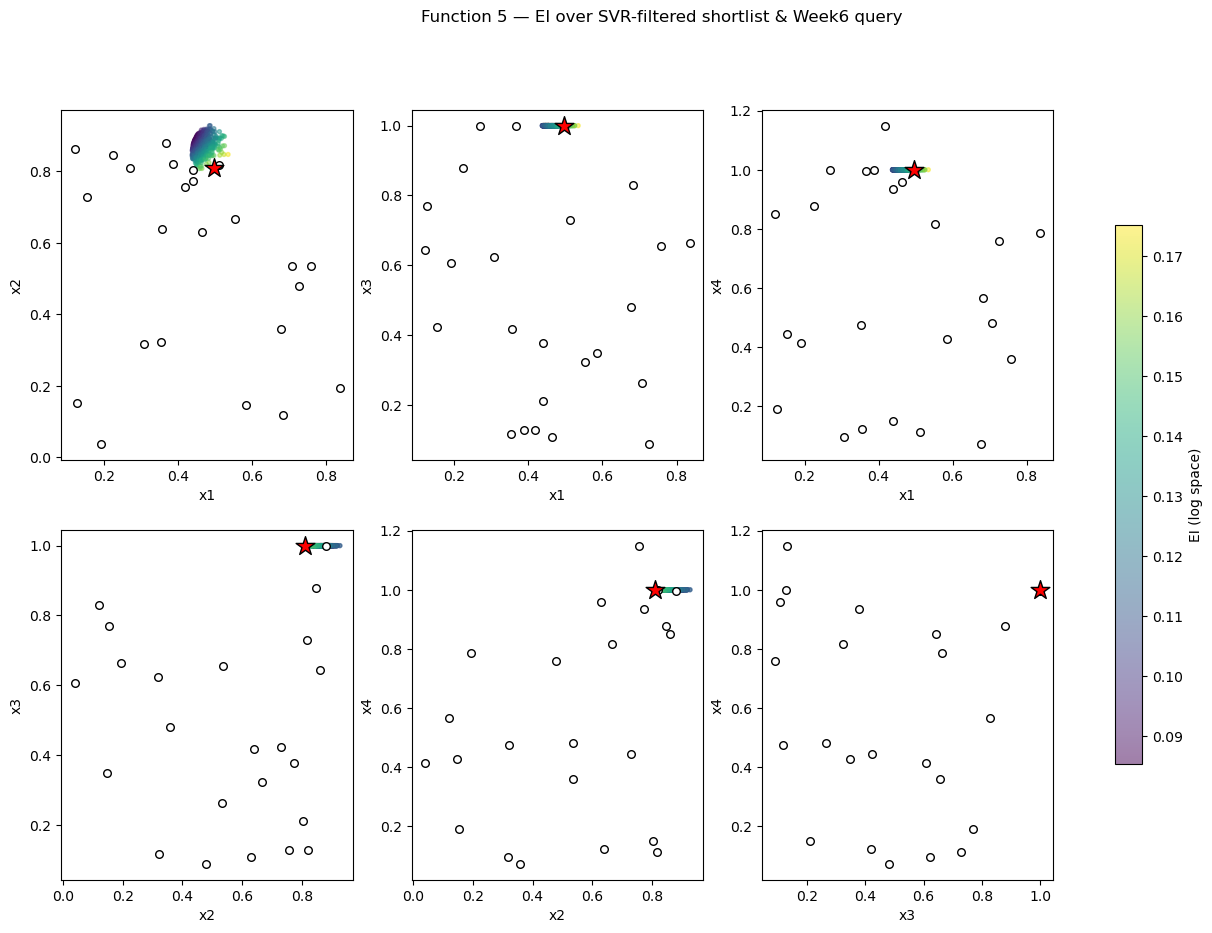

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
dims = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
labels = ['x1', 'x2', 'x3', 'x4']

for ax, (i, j) in zip(axes.ravel(), dims):
    sc = ax.scatter(filtered[:, i], filtered[:, j], c=ei_F5,
                     cmap='viridis', s=8, alpha=0.5)
    ax.scatter(all_inputs_F5[:, i], all_inputs_F5[:, j], c='white', edgecolor='k', s=30)
    ax.scatter(query_F5[i], query_F5[j], c='red', marker='*', s=200, edgecolor='k')
    ax.set_xlabel(labels[i]); ax.set_ylabel(labels[j])

fig.colorbar(sc, ax=axes, label='EI (log space)', shrink=0.7)
fig.suptitle('Function 5 — EI over SVR-filtered shortlist & Week6 query')
plt.show()

# Function 6, A cake recipe, 5D array, 20 original samples - Week 6

In [37]:
# =============================================================================
# FUNCTION 6 - A cake recipe, 5D array, 20 original samples
# =============================================================================
# Previous weeks
# W3: ARD GP + EI (ξ = 0.05) over a mixed candidate pool consisting of uniform random samples, 
#     Latin Hypercube Sampling (LHS), and perturbations around the top five recipes.
# W4: GP with ARD Matérn + EI (ξ = 0.02)
# W5: RF surrogate (200 trees); acquisition via Thompson sampling using a single randomly selected decision tree rather than the ensemble mean

# change: Combines Maximin LHS for space-filling coverage with a full RF ensemble 
#         to balance high-dimensional exploration and exploitation.


print("\n" + "=" * 60)
print("Function 6 - Week 6")
print("=" * 60)

# Step 1: Load data and fold in previous weeks' queries.
f6_inputs  = np.load('initial_data/function_6/initial_inputs.npy')
f6_outputs = np.load('initial_data/function_6/initial_outputs.npy')

prev_queries_F6 = np.array([
    [0.939456, 0.643603, 0.531941, 1.031640, 0.012391],              # W2
    [0.463219, 0.306404, 0.635240, 0.999844, 0.015672],              # W3
    [0.344063, 0.007363, 0.627449, 0.999999, 0.004891],              # W4
    [0.611853, 0.139494, 0.292145, 0.366362, 0.456070],              # W5
])
prev_outputs_F6 = np.array([-1.241946, -0.352945, -0.837300, -1.468430])

all_inputs_F6  = np.vstack([f6_inputs, prev_queries_F6])
all_outputs_F6 = np.hstack([f6_outputs, prev_outputs_F6])

print(f"Total observations: {all_inputs_F6.shape[0]}, best (max): {all_outputs_F6.max():.4f}")


Function 6 - Week 6
Total observations: 24, best (max): -0.3529


In [38]:
# Step 2: Fit the Random Forest surrogate.
# Why n_estimators=500 with no depth cap this time (unlike Function 2, 
#   which explicitly capped depth at 3): this function's output looks smoother/less noisy than Function 2's, 
#   so unrestricted tree depth is kept; instead, the number of trees was increased specifically
#   to get a more stable estimate of cross-tree variance for the uncertainty calculation in Step 5.

rf_F6 = RandomForestRegressor(n_estimators=500, random_state=42)
rf_F6.fit(all_inputs_F6, all_outputs_F6)

RandomForestRegressor(n_estimators=500, random_state=42)

In [39]:
# Step 3: Inspect feature importances.
# Purpose: a quick check on which of the 5 recipe ingredients the surrogate currently considers most influential, 
#  useful context for interpreting the query chosen below.

print("\nRandom Forest feature importances:")
for i, importance in enumerate(rf_F6.feature_importances_):
    print(f"  x{i+1}: {importance:.4f}")


Random Forest feature importances:
  x1: 0.0704
  x2: 0.1313
  x3: 0.0558
  x4: 0.2924
  x5: 0.4501


In [40]:
# Step 4: Candidate generation via maximin Latin Hypercube Sampling.
# What I tried before: plain uniform random candidate generation.
# What I chose instead: a maximin-criterion LHS design, which explicitly
#   maximises the minimum distance between any two candidates. 
#   This guarantees the pool is evenly spread across the 5D unit cube 
#   rather than risking the clustering/gaps that pure random sampling can produce —
#   important here because the acquisition function in Step 5 relies on cross-tree standard deviation, 
#   which is only meaningful if the candidate pool actually covers the space well.

space_F6      = Space([(0.0, 1.0)] * 5)
lhs_F6        = Lhs(criterion="maximin", iterations=100)
candidates_F6 = np.array(lhs_F6.generate(space_F6.dimensions, 5000))

In [41]:
# Step 5: Full-ensemble UCB acquisition.
# Why collect predictions from every individual tree (rather than using a single sampled tree 
#   as in Function 2, or the RF's default variance  estimate, which sklearn doesn't expose directly): 
#   looping over every tree in the forest and taking mean/std across all of them gives a direct,
#   literal estimate of how much the ensemble disagrees with itself at each candidate —
#   a natural proxy for predictive uncertainty.
# Why kappa=1.5: a moderate exploration weight, less aggressive than
#   Function 1's kappa=4.0 because this surrogate is trained on more data 
#   (24 points) and considered more trustworthy already.

print("\n" + "=" * 60)
print("Function 6 - Week 6")
print("=" * 60)

kappa      = 1.5
tree_preds = np.array([t.predict(candidates_F6) for t in rf_F6.estimators_])
mean_pred  = tree_preds.mean(axis=0)
std_pred   = tree_preds.std(axis=0)
ucb_scores = mean_pred + kappa * std_pred

best_index_F6 = np.argmax(ucb_scores)
query_F6      = candidates_F6[best_index_F6]

print(f"\nWeek 6 Query: {format_query(query_F6)}")
print(f"  Predicted mean: {mean_pred[best_index_F6]:.4f}")
print(f"  Predicted std:  {std_pred[best_index_F6]:.4f}")
print(f"  UCB score:      {ucb_scores[best_index_F6]:.4f}  (kappa={kappa})")


Function 6 - Week 6

Week 6 Query: 0.362372-0.287752-0.659391-0.946547-0.011897
  Predicted mean: -0.7124
  Predicted std:  0.3900
  UCB score:      -0.1275  (kappa=1.5)


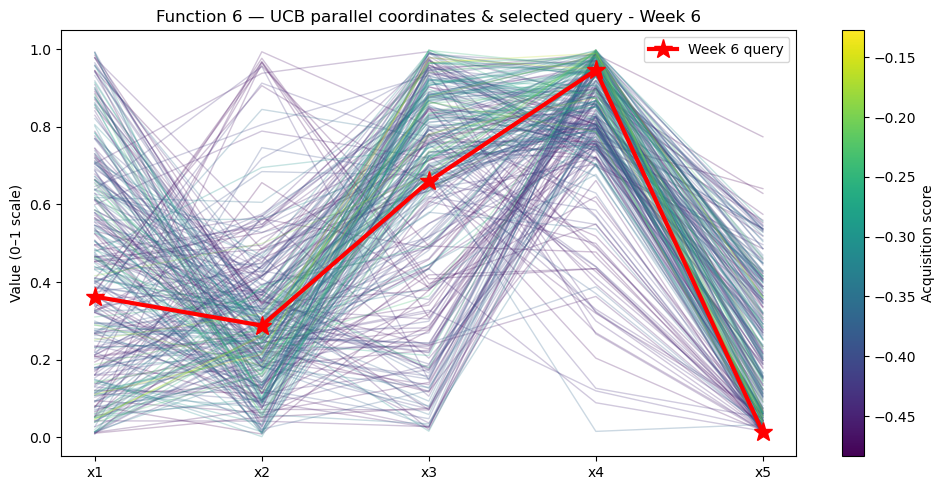

In [42]:
plot_parallel_coordinates(
    candidates_F6, ucb_scores, query_F6,
    dim_labels=['x1', 'x2', 'x3', 'x4', 'x5'],
    title='Function 6 — UCB parallel coordinates & selected query - Week 6'
)

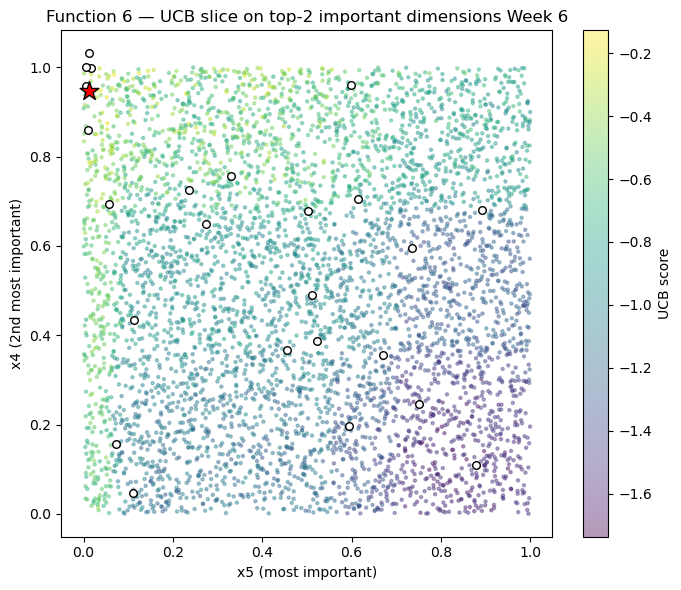

In [43]:
top2 = np.argsort(rf_F6.feature_importances_)[::-1][:2]
i, j = top2

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(candidates_F6[:, i], candidates_F6[:, j], c=ucb_scores,
                 cmap='viridis', s=5, alpha=0.4)
ax.scatter(all_inputs_F6[:, i], all_inputs_F6[:, j], c='white', edgecolor='k', s=30)
ax.scatter(query_F6[i], query_F6[j], c='red', marker='*', s=200, edgecolor='k')
plt.colorbar(sc, label='UCB score')
ax.set_xlabel(f'x{i+1} (most important)'); ax.set_ylabel(f'x{j+1} (2nd most important)')
ax.set_title('Function 6 — UCB slice on top-2 important dimensions Week 6')
plt.tight_layout()
plt.show()

# Function 7, Unspecified field, 6D array, 30 original samples - Week 6

In [44]:
# =============================================================================
# FUNCTION 7 - Unspecified field, 6D array, 30 original samples
# =============================================================================
# Previous weeks
# W3: Strong exploitation vis Random Forest + SHAP identifies influential variables and preferred directions
# W4: GP EI (on log1p outputs, ξ = 0.01) + MLP regressor (50/50 blend)
# W5: Two-stage approach: RBF interpolator (multiquadric kernel) scores the full candidate set, 
#     then RF re-ranks the top 1,000 candidates

# change: Uses RF feature importance to filter down key dimensions 
#        before running a gradient-based UCB search via an ARD GP.

print("\n" + "=" * 60)
print("Function 7 - Week 6")
print("=" * 60)

# Step 1: Load data and fold in previous weeks' queries.
f7_inputs  = np.load('initial_data/function_7/initial_inputs.npy')
f7_outputs = np.load('initial_data/function_7/initial_outputs.npy')

prev_queries_F7 = np.array([
    [0.079933, 0.633654, 0.734486, 0.864915, 0.103811, 0.933346],    # W2
    [0.020000, 0.229276, 0.478532, 0.247457, 0.365999, 0.737383],    # W3
    [0.012357, 0.162903	, 0.399853, 0.082758, 0.249752, 0.923732],   # W4
    [0.042283, 0.348468, 0.793617, 0.259525, 0.456849, 0.822122],    # W5
])
prev_outputs_F7 = np.array([0.59279, 2.59480, 1.08804, 1.31103])

all_inputs_F7  = np.vstack([f7_inputs, prev_queries_F7])
all_outputs_F7 = np.hstack([f7_outputs, prev_outputs_F7])
log_outputs_F7 = np.log1p(all_outputs_F7)

print(f"Total points: {len(all_outputs_F7)}, best (max): {all_outputs_F7.max():.4f}")


Function 7 - Week 6
Total points: 34, best (max): 2.5948


In [45]:
# Step 2: Random Forest feature importance.
# Purpose: with 6 input dimensions and only 34 points, a full 6D global search is data-starved. 
#  Before fitting the final surrogate, we first fit a quick  RF purely to rank 
#  which of the 6 hyperparameters the output is most  sensitive to — 
#  this ranking is then used in Step 3 to deliberately shrink the search space.

print("\nStep 1: Random Forest")
feature_names = [f"HP{i+1}" for i in range(6)]

rf_F7 = RandomForestRegressor(n_estimators=200, random_state=42)
rf_F7.fit(all_inputs_F7, all_outputs_F7)

print("\nRF Feature Importance:")
for name, importance in zip(feature_names, rf_F7.feature_importances_):
    print(f"  {name}: {importance:.3f}")


Step 1: Random Forest

RF Feature Importance:
  HP1: 0.713
  HP2: 0.048
  HP3: 0.045
  HP4: 0.029
  HP5: 0.076
  HP6: 0.090


In [46]:
# Step 3: Subspace definition from feature importance.
# The core idea: width = 1 - importance means a HIGH-importance dimension gets a NARROW search window 
#   and a low-importance dimension gets a WIDE one. 
#   This is deliberate: if the output is very sensitive to a dimension,
#   a wrong value there is costly, so I exploit what I already know about
#   where it should sit rather than re-exploring its whole range; 
#   if the output barely responds to a dimension, there's little to lose by letting it roam freely.
   
# HP1 and HP6 additionally get manual, hard-coded bounds on top of 
#   the importance-derived width: HP1's lower bound (0.02) and HP6's whole window ([0.60, 0.85]) 
#   are set from where previous weeks' good queries actually landed — 
#   domain knowledge overriding the purely statistical importance ranking for these two dimensions specifically.

# Net effect: this narrows an intractable 6D global search down to 
#   a much smaller, targeted region, given only 34 total observations.

print("\nStep 2: Subspace Definition")

importance    = rf_F7.feature_importances_
width         = 1.0 - importance

subspace_lower = np.array([0.02, 0.0, 0.0, 0.0, 0.0, 0.60])
subspace_upper = np.array([width[0], 1.0, 1.0, 1.0, 1.0, 0.85])

subspace_lower = np.clip(subspace_lower, 0, 1)
subspace_upper = np.clip(subspace_upper, 0, 1)

print("\nSubspace bounds:")
for name, low, high, imp in zip(feature_names, subspace_lower, subspace_upper, importance):
    print(f"  {name}: [{low:.3f}, {high:.3f}]  (importance {imp:.3f})")



Step 2: Subspace Definition

Subspace bounds:
  HP1: [0.020, 0.287]  (importance 0.713)
  HP2: [0.000, 1.000]  (importance 0.048)
  HP3: [0.000, 1.000]  (importance 0.045)
  HP4: [0.000, 1.000]  (importance 0.029)
  HP5: [0.000, 1.000]  (importance 0.076)
  HP6: [0.600, 0.850]  (importance 0.090)


In [47]:
# Step 4: Fit the refinement GP.
# Why ARD length scales (one per dimension, all starting at 0.3) with 
#   wide bounds (0.05, 5.0) rather than fixed/tight bounds like Functions 1/4/5:
#   here we deliberately let the optimiser adapt each dimension's scale  freely from the data,
#   since the importance-driven subspace narrowing above already did the heavy lifting of 
#   constraining WHERE to search — the GP's job is now just to fit the response shape well within that region.

# Why log1p the output again: F7's outputs range from ~0.59 to ~2.59+, a  wide-enough relative
#   spread that log-space keeps the GP's noise assumptions closer to valid.

print("\nStep 3: GP with UCB")

kernel_F7 = ConstantKernel(1.0, (0.01, 10.0)) * Matern(
    length_scale=[0.3] * 6,
    length_scale_bounds=(0.05, 5.0),
    nu=2.5,
)
gp_F7 = GaussianProcessRegressor(
    kernel=kernel_F7,
    n_restarts_optimizer=20,
    normalize_y=True,
)
gp_F7.fit(all_inputs_F7, np.log1p(all_outputs_F7))


Step 3: GP with UCB


GaussianProcessRegressor(kernel=1**2 * Matern(length_scale=[0.3, 0.3, 0.3, 0.3, 0.3, 0.3], nu=2.5),
                         n_restarts_optimizer=20, normalize_y=True)

In [48]:
# Step 5: Multi-start continuous optimisation of UCB inside the subspace.
# Why a gradient-based optimiser (L-BFGS-B) over a discretised candidate grid here, 
#   unlike every other function above: once the search space has already been narrowed to a small subspace,
#   it becomes worth polishing the  acquisition surface precisely with
#   a continuous optimiser rather than relying on how densely a random/LHS grid 
#   happens to cover that (now small) region.
# Why 500 random restarts: the UCB(mu, sigma) surface from a GP is generally multimodal, 
#   so a single L-BFGS-B run can get stuck in a local optimum;
#   restarting from many random starting points inside the subspace bounds
#   makes it much more likely the global optimum within the subspace is found.

print("\n" + "=" * 60)
print("Function 7 - Week 6")
print("=" * 60)


def negative_ucb(candidate_F7, gp_F7, kappa=2.0):
    candidate_F7 = candidate_F7.reshape(1, -1)
    mean_F7, std_F7 = gp_F7.predict(candidate_F7, return_std=True)
    return -(mean_F7[0] + kappa * std_F7[0])


bounds = list(zip(subspace_lower, subspace_upper))

best_ucb_value = np.inf
best_candidate = None

np.random.seed(42)
for _ in range(500):
    start = np.array([np.random.uniform(low, high) for low, high in bounds])
    result = minimize(
        negative_ucb,
        start,
        args=(gp_F7,),
        bounds=bounds,
        method="L-BFGS-B",
    )
    if result.fun < best_ucb_value:
        best_ucb_value = result.fun
        best_candidate_F7 = result.x

predicted_mean, predicted_std = gp_F7.predict(best_candidate_F7.reshape(1, -1), return_std=True)
predicted_y = np.expm1(predicted_mean[0])

print(f"\nWeek 6 Query: {format_query(best_candidate_F7)}")
print(f"\nGP predicted Y (original scale) : {predicted_y:.4f}")
print(f"GP uncertainty (log scale std)  : {predicted_std[0]:.4f}")


Function 7 - Week 6

Week 6 Query: 0.020000-0.084621-0.685564-0.148317-0.347709-0.669559

GP predicted Y (original scale) : 2.4217
GP uncertainty (log scale std)  : 0.1076


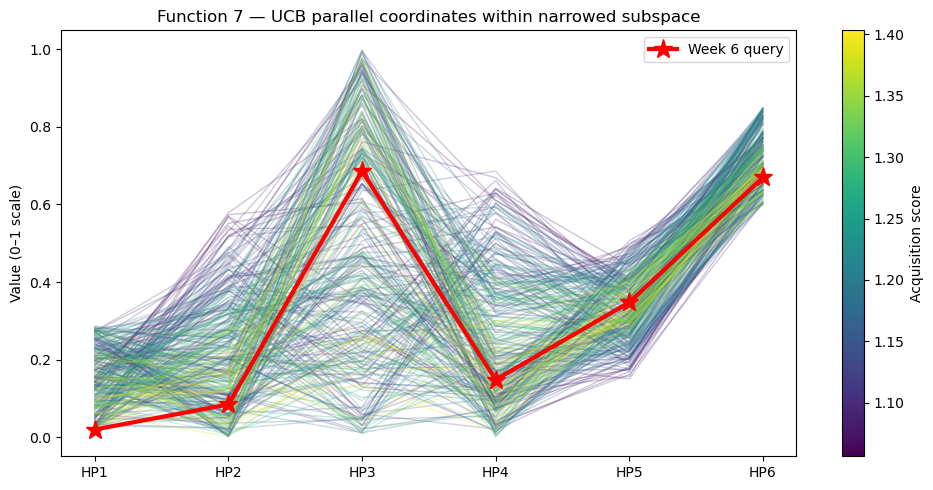

In [49]:
np.random.seed(0)
vis_candidates_F7 = np.column_stack([
    np.random.uniform(low, high, 4000) for low, high in bounds
])
mu_vis_F7, sigma_vis_F7 = gp_F7.predict(vis_candidates_F7, return_std=True)
ucb_vis_F7 = mu_vis_F7 + 2.0 * sigma_vis_F7  # same kappa as negative_ucb default

plot_parallel_coordinates(
    vis_candidates_F7, ucb_vis_F7, best_candidate_F7,
    dim_labels=[f'HP{i+1}' for i in range(6)],
    title='Function 7 — UCB parallel coordinates within narrowed subspace'
)

# Function 8, Unspecified field, 8D array, 40 original samples - Week 6

In [50]:
# =============================================================================
# FUNCTION 8 - Unspecified field, 8D array, 40 original samples
# =============================================================================
# Previous weeks
# W3: Pipeline (a) combines partial exploration (free dimensions) with strong exploitation (pinned dimensions); 
#     Pipeline (b) is almost entirely exploitation-focused.
# W4: GP (ARD Matérn) UCB (κ = 2.0) + MLP regressor (50/50 blend)
# W5: MC-Dropout MLP (2 hidden layers, dropout active during inference with 50 stochastic forward passes); acquisition = UCB (κ = 3.0)

# change: Scales high-dimensional inputs and leverages Monte Carlo Dropout in a neural network 
#         to quantify uncertainty for UCB optimisation.

print("\n" + "=" * 60)
print("Function 8 - Week 6")
print("=" * 60)

# Step 1: Load data and fold in previous weeks' queries.
# Why a neural network for this function specifically (the only one in the notebook):
#   at 8 input dimensions this is the highest-dimensional function here, 
#   and also has the largest sample budget (40 points). 
#   A kernel-based GP surrogate scales poorly as dimensionality grows 
#   (the curse of dimensionality makes distance-based kernels less informative), 
#   whereas a small, regularised MLP can still learn a useful 8D mapping with 
#   a moderate number of points, provided overfitting is actively controlled
#   (see the dropout/architecture choices in Step 5 below).

import torch
import torch.nn as nn

# Step 1: Load data and fold in previous weeks' queries.
f8_inputs  = np.load('initial_data/function_8/initial_inputs.npy')
f8_outputs = np.load('initial_data/function_8/initial_outputs.npy')

prev_queries_F8 = np.array([
    [0.034736, 0.033935, 0.577646, 0.735810, 0.807192, 0.026536, 0.72178, 0.629862],     #W2
    [0.019981, 0.000000, 0.999999, 0.000000, 0.448273, 0.855526, 0.446219, 0.931836],    #W3
    [0.035148, 0.000000, 0.018976, 0.000000, 0.999999, 0.361194, 0.007310, 0.000000],    #W4
    [0.040725, 0.748531, 0.178080, 0.981020, 0.988831, 0.993927, 0.013038, 0.216952],    #W5
])
prev_outputs_F8 = np.array([8.26488, 7.35099, 9.76008, 8.590830])

all_inputs_F8  = np.vstack([f8_inputs, prev_queries_F8])
all_outputs_F8 = np.hstack([f8_outputs, prev_outputs_F8])

print(f"Total points: {len(all_outputs_F8)}, best: {all_outputs_F8.max():.4f}")


Function 8 - Week 6
Total points: 44, best: 9.7601


In [51]:
# Step 2: Standardise inputs and outputs.
# Why standardise separately for X and y: neural nets trained with Adam converge far 
#   more reliably when both inputs and targets are on a similar, well-conditioned scale. 
#   Keeping separate scaler objects also lets us invert predictions back to the original output scale later.

scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_sc = scaler_x.fit_transform(all_inputs_F8)
Y_sc = scaler_y.fit_transform(all_outputs_F8.reshape(-1, 1)).ravel()

In [52]:
# Step 3: Convert to torch tensors for training.

X_tensor = torch.tensor(X_sc, dtype=torch.float32)
Y_tensor = torch.tensor(Y_sc, dtype=torch.float32).unsqueeze(1)

In [53]:
# Step 4: Monte Carlo (MC) Dropout prediction helper.
# How this gives uncertainty from a plain feed-forward net: calling  model.train() (rather than model.eval())
#   keeps dropout ACTIVE during  prediction, so each forward pass randomly drops
#   a different subset of hidden units and produces a slightly different output. 
#   Averaging many such passes gives a mean prediction, 
#   while the spread (std) across passes approximates predictive uncertainty — 
#   a cheap stand-in for a full Bayesian neural network, reusing dropout 
#   (already present for regularisation) as an uncertainty-estimation mechanism too.

def mc_predict(model, X_tensor, n_passes=50):
    model.train()
    preds = torch.stack([model(X_tensor).squeeze() for _ in range(n_passes)])
    return preds.mean(dim=0).detach().numpy(), preds.std(dim=0).detach().numpy()


In [54]:
# Step 5: Model architecture.
# Why only 2 hidden layers, 24 units wide (8 -> 24 -> 24 -> 1): with just 40 training points across 8 dimensions, 
#   a deeper/wider network would almost certainly overfit; 
#   this is a deliberately modest capacity chosen to match the small sample size.

# Why dropout_rate=0.2 (increased from Week 5's 0.1, with hidden_dim reduced from 32 to 24): 
#   this trade-off — smaller layers, stronger dropout — was a direct response to
#    Week 5's calibration diagnostics (see Step 6/7 below) suggesting the previous model was 
#   too confident relative to its actual error, 
#   i.e. some capacity was deliberately given up in exchange for stronger regularisation.

class DropoutMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)

In [55]:
# Step 6: Leave-One-Out (LOO) calibration loop.
# Purpose: before trusting the MC-dropout uncertainty estimates for acquisition, 
#   I check whether they're actually well-calibrated. 
#   For each of the 40 points in turn: hold it out, fit a FRESH model 
#   (with fresh  scalers, to avoid any leakage from the held-out point) 
#   on the remaining 39 points, then use MC dropout to predict the held-out point and 
#   record both the true error and the predicted sigma.

loo_errors = []
loo_sigmas = []

for i in range(len(all_outputs_F8)):
    # hold out point i
    X_train_loo = np.delete(all_inputs_F8, i, axis=0)
    y_train_loo = np.delete(all_outputs_F8, i)
    X_test_loo  = all_inputs_F8[i:i+1]
    y_test_loo  = all_outputs_F8[i]

    # fit scalers on training fold only -- no leakage
    sx_loo = StandardScaler()
    sy_loo = StandardScaler()
    X_tr_sc_loo = sx_loo.fit_transform(X_train_loo)
    y_tr_sc_loo = sy_loo.fit_transform(y_train_loo.reshape(-1, 1)).ravel()
    X_te_sc_loo = sx_loo.transform(X_test_loo)

    X_tr_tensor = torch.tensor(X_tr_sc_loo, dtype=torch.float32)
    Y_tr_tensor = torch.tensor(y_tr_sc_loo, dtype=torch.float32).unsqueeze(1)
    X_te_tensor = torch.tensor(X_te_sc_loo, dtype=torch.float32)

    # fresh model for each fold
    torch.manual_seed(42)
    model_loo     = DropoutMLP(input_dim=8, hidden_dim=24, dropout_rate=0.2)
    optimiser_loo = torch.optim.Adam(model_loo.parameters(), lr=1e-3)

    model_loo.train()
    for epoch in range(1000):
        optimiser_loo.zero_grad()
        loss_loo = nn.MSELoss()(model_loo(X_tr_tensor), Y_tr_tensor)
        loss_loo.backward()
        optimiser_loo.step()

    mu_sc_loo, sigma_sc_loo = mc_predict(model_loo, X_te_tensor, n_passes=50)
    mu_loo    = sy_loo.inverse_transform(mu_sc_loo.reshape(-1, 1)).ravel()[0]
    sigma_loo = np.atleast_1d(sigma_sc_loo)[0] * sy_loo.scale_[0]

    loo_errors.append(abs(mu_loo - y_test_loo))
    loo_sigmas.append(sigma_loo)


In [56]:
# Step 7: Summarise LOO calibration.
# How to read the ratio: 
#   error/sigma ~ 1.0 means  the model's predicted uncertainty matches its actual mistakes well; 
#   > 1.0 means the model is OVER-confident (errors bigger than the sigma it reports, 
#   so kappa should probably be increased to compensate 
#   when using this sigma for acquisition); < 1.0 means it's under-confident.

loo_errors = np.array(loo_errors)
loo_sigmas = np.array(loo_sigmas)

kappa = 1.7  # W5: 3.0

print(f"\nLOO Calibration (true torch model):")
print(f"  mean |error|:        {loo_errors.mean():.4f}")
print(f"  std  |error|:        {loo_errors.std():.4f}")
print(f"  max  |error|:        {loo_errors.max():.4f}")
print(f"  mean sigma (LOO):    {loo_sigmas.mean():.4f}")
print(f"  ratio (error/sigma): {loo_errors.mean() / loo_sigmas.mean():.3f}  (1.0 = perfect calibration)")
print(f"  suggested kappa:     {kappa * (loo_errors.mean() / loo_sigmas.mean()):.2f}")



LOO Calibration (true torch model):
  mean |error|:        0.3209
  std  |error|:        0.2971
  max  |error|:        1.0101
  mean sigma (LOO):    0.2461
  ratio (error/sigma): 1.304  (1.0 = perfect calibration)
  suggested kappa:     2.22


In [57]:
# Step 8: Train the final deployed model on ALL 40 points.
# Why retrain from scratch on the full dataset rather than reusing one of the LOO folds: 
#   Step 6/7 was purely a diagnostic on held-out calibration; the model we actually use to pick 
#   this week's query should make use of every available observation, not leave one out.

torch.manual_seed(42)
model     = DropoutMLP(input_dim=8, hidden_dim=24, dropout_rate=0.2)  # W5: hidden=32, dropout=0.1
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()

model.train()
for epoch in range(1000):
    optimiser.zero_grad()
    pred = model(X_tensor)
    loss = loss_fn(pred, Y_tensor)
    loss.backward()
    optimiser.step()

print(f"Training loss (final): {loss.item():.4f}")

Training loss (final): 0.0763


In [58]:
# Step 9: Candidate pool via Latin Hypercube Sampling.
# Why LHS again (as in Function 6) rather than plain uniform random: 
#   in 8 dimensions, uniform random sampling is even more prone to leaving gaps or
#   under-sampling corners of the space than in lower dimensions; 
#   a space-filling LHS design of 50,000 points gives more even coverage of the  8D unit cube for the same sample budget.

n    = 50000
pool = LatinHypercube(d=8, seed=42).random(n=n)

pool_sc     = scaler_x.transform(pool)
pool_tensor = torch.tensor(pool_sc, dtype=torch.float32)

mu_sc, sigma_sc = mc_predict(model, pool_tensor, n_passes=50)

In [59]:
# Step 10: UCB acquisition using MC-dropout uncertainty.
# Why kappa=1.7, down from Week 5's 3.0: this is a MORE exploitative setting than the previous week.
# The choice here leans more exploitative instead,  
#   plausibly because the best-observed output (9.76) is already strong and later in a search 
#   it can be reasonable to prioritise refining around a good optimum over continuing broad exploration.
#   It is flagged here as a discrepancy against the calibration diagnostic
#   rather than a value directly justified by it, and would be worth revisiting.

print("\n" + "=" * 60)
print("Function 8 - Week 6")
print("=" * 60)

mu_F8    = scaler_y.inverse_transform(mu_sc.reshape(-1, 1)).ravel()
sigma_F8 = sigma_sc * scaler_y.scale_[0]

ucb_F8   = mu_F8 + kappa * sigma_F8
best_idx_F8 = np.argmax(ucb_F8)
query_F8    = pool[best_idx_F8]

print(f"mu   range: {mu_F8.min():.3f} to {mu_F8.max():.3f}")
print(f"sigma range: {sigma_F8.min():.3f} to {sigma_F8.max():.3f}")
print(f"kappa*sigma range: {(kappa*sigma_F8).min():.3f} to {(kappa*sigma_F8).max():.3f}")

print(f"\nWeek 6 Query: {format_query(query_F8)}")
print(f"MC mu: {mu_F8[best_idx_F8]:.4f}, sigma: {sigma_F8[best_idx_F8]:.4f}")
print(f"UCB:   {ucb_F8[best_idx_F8]:.4f}")


Function 8 - Week 6
mu   range: 5.200 to 9.877
sigma range: 0.068 to 0.640
kappa*sigma range: 0.116 to 1.088

Week 6 Query: 0.060495-0.027090-0.006185-0.132068-0.160719-0.354431-0.001361-0.931902
MC mu: 9.8767, sigma: 0.3866
UCB:   10.5340


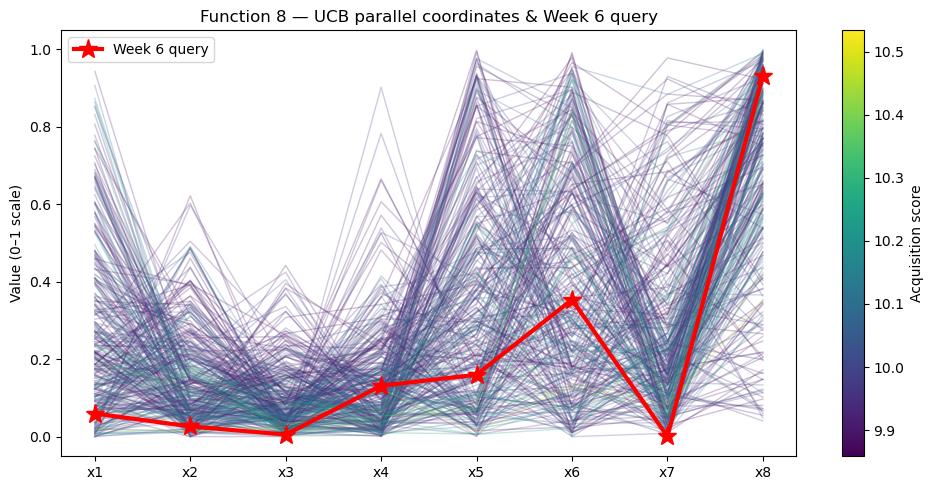

In [60]:
plot_parallel_coordinates(
    pool, ucb_F8, query_F8,
    dim_labels=[f'x{i+1}' for i in range(8)],
    title='Function 8 — UCB parallel coordinates & Week 6 query'
)

# Summary 

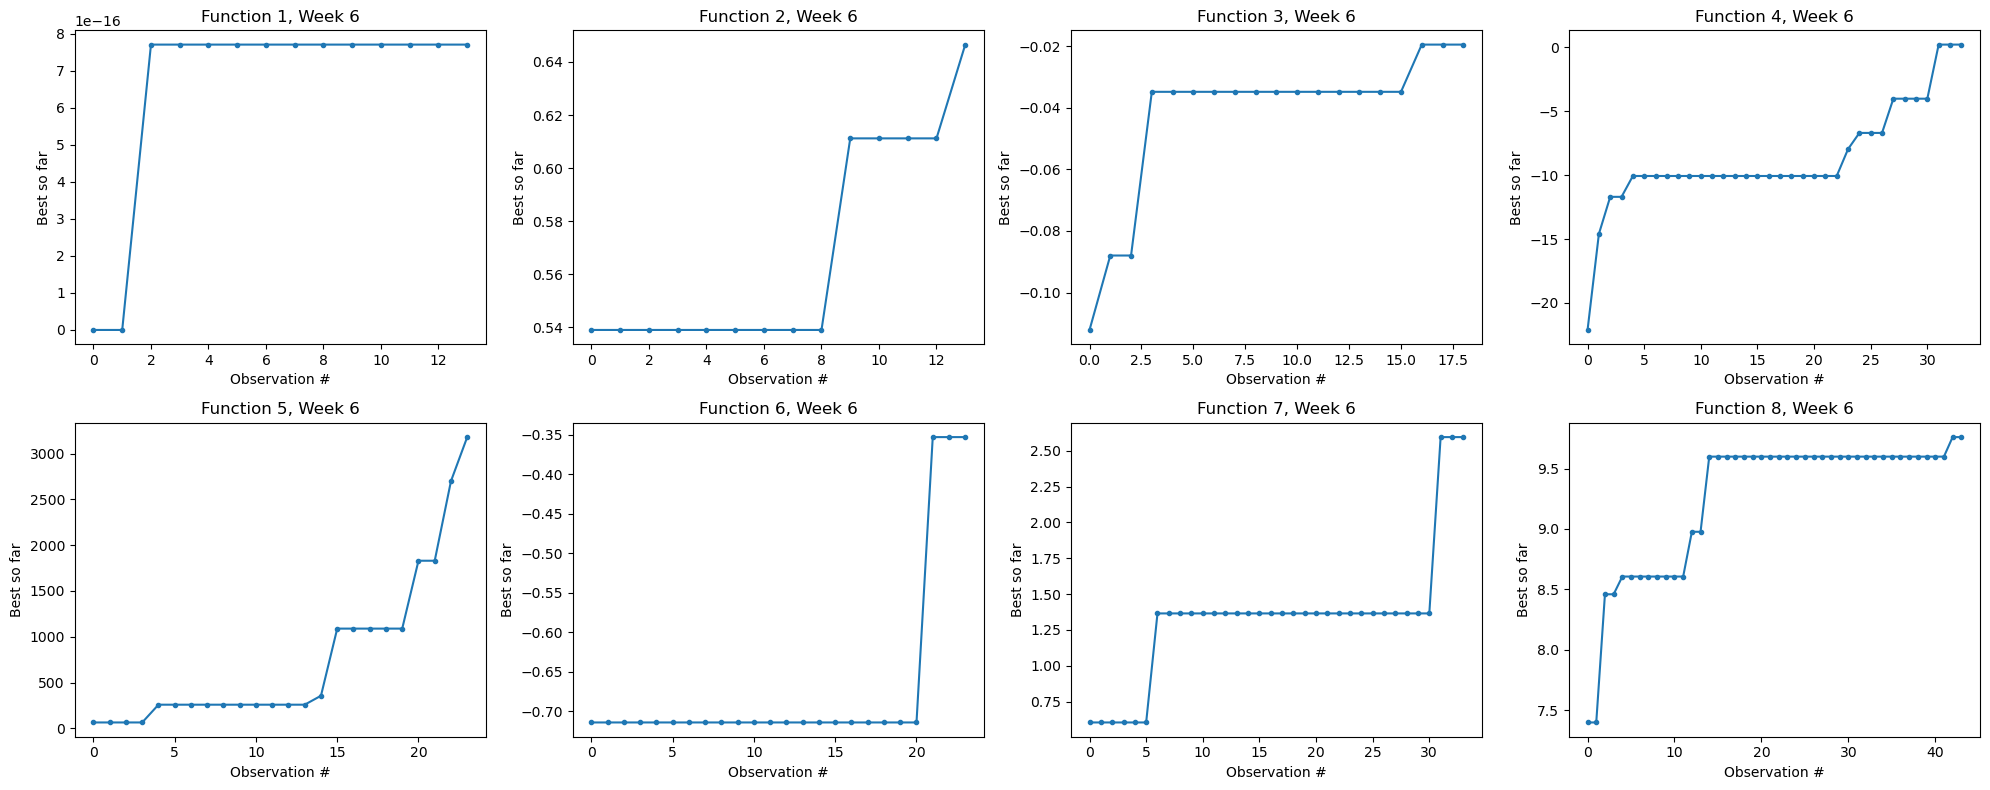

In [61]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
all_outputs = {
    1: all_outputs_F1, 2: all_outputs_F2, 3: Y, 4: all_outputs_F4,
    5: all_outputs_F5, 6: all_outputs_F6, 7: all_outputs_F7, 8: all_outputs_F8,
}
for ax, (fn, outputs) in zip(axes.ravel(), all_outputs.items()):
    running_best = np.maximum.accumulate(outputs)
    ax.plot(running_best, marker='o', markersize=3)
    ax.set_title(f'Function {fn}, Week 6')
    ax.set_xlabel('Observation #'); ax.set_ylabel('Best so far')
plt.tight_layout()
plt.show()